## Import  Library 

In [30]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from scipy.stats import binom,lognorm,boxcox
from scipy.stats import poisson,powerlaw
from scipy.stats import zscore, norm


In [24]:
df = pd.read_csv("spread_locator_dataset.csv")


##  Bernoulli & Binomial

* Bernoulli models single trial (0/1).  
* Binomial counts successes in multiple trials.

In [25]:
data = np.random.choice([0,1], size=100)
p = data.mean()

print("p:", p)
print("Binomial:", binom.pmf(range(5), 4, p))

p: 0.55
Binomial: [0.04100625 0.200475   0.3675375  0.299475   0.09150625]


## Poisson

* Models number of events in fixed interval.  
* Assumes constant rate and independence.

In [26]:
data = np.random.poisson(lam=3, size=100)
lam = data.mean()

print("Lambda:", lam)
print("Poisson:", poisson.pmf(range(5), lam))

Lambda: 2.94
Poisson: [0.05286573 0.15542524 0.22847511 0.2239056  0.16457062]


##  Log-Normal & Power Law
* Log-normal handles positive skewed data.  
* Power law models heavy-tailed data.

In [27]:
data = np.random.lognormal(3,1,1000)

print(lognorm.fit(data))
print(powerlaw.fit(data))

(np.float64(1.0288444490964692), 0.36895451204381313, np.float64(20.28117502696554))
(np.float64(0.33766673882547704), np.float64(0.8851449250951382), np.float64(361.51811162669907))


##  Q-Q Plot

* Compares data with theoretical distribution.  
* Straight line ⇒ normal distribution.

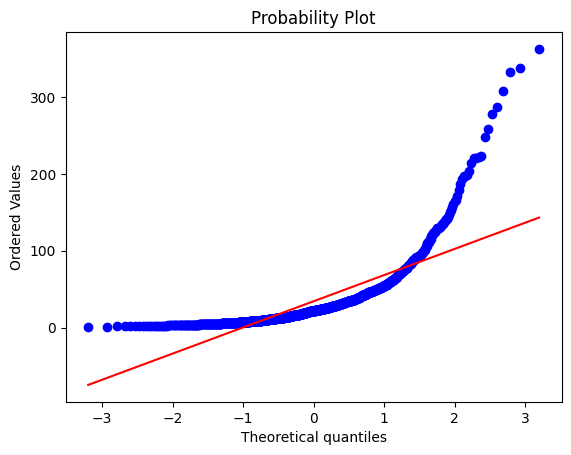

In [28]:
stats.probplot(data, dist="norm", plot=plt)
plt.show()

## Box-Cox
* Used to normalize data and stabilize variance.  
* Works only for positive values.

In [29]:
transformed, l = boxcox(data)
print("Lambda:", l)

Lambda: -0.016475455497864167


## Z-score

* Measures distance from mean in std units.  
* Used for outliers and probability.

In [31]:
z = zscore(data)
prob = 1 - norm.cdf(5000, data.mean(), data.std())

print("Prob > 5000:", prob)

Prob > 5000: 0.0


##  PDF & CDF

* PDF shows density.  
* CDF shows cumulative probability.

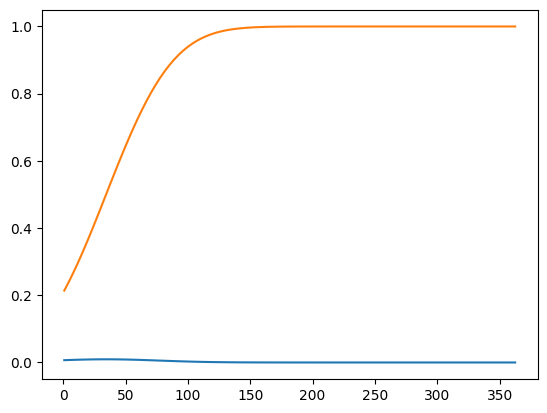

In [32]:
x = np.linspace(min(data), max(data), 100)

plt.plot(x, norm.pdf(x, data.mean(), data.std()))
plt.plot(x, norm.cdf(x, data.mean(), data.std()))
plt.show()

##  Conclusion

* Choose best distribution using plots & stats.  
* Log-normal often fits skewed data well.

In [33]:
print("Log-normal fits best for skewed data")

Log-normal fits best for skewed data
